In [1]:
# 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from workalendar.asia import SouthKorea 

# statsmodel 확인
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool, cpu_count
from torch.utils.data import DataLoader, TensorDataset

# 오류 무시하는 방법
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv("/mnt/nvme/zongseung/SCI/기후데이터/demand_celcius.csv")
df = df.set_index("일시")
df = df.drop("Unnamed: 0", axis=1)
df.index = pd.to_datetime(df.index)

In [3]:
import datetime as dt
cal = SouthKorea()

def holiday_weekday(data):
    holiday_data = []

    for date in data.index:

        if date.weekday() in [5, 6] or cal.is_holiday(date) is True:  # 주말 (토요일=5, 일요일=6) / 공휴일까지 포함시켜서 확인한다.
            holiday_data.append(2) # 2번은 쉬는날
        else:  # 그 외 날짜 
            holiday_data.append(1) # 안쉬는날

    data["holiday_data"] = holiday_data    
    
    return data

def get_season_by_month(month):
    asd = []
    
    for i in month: 
        if 3 <= i <= 5: 
            asd.append(1) # 봄
        elif 6 <= i <= 8:
            asd.append(2) # 여름
        elif 9 <= i <= 11:
            asd.append(3)
        else:
            asd.append(4)
    return asd

In [4]:
df["month"] = df.index.month

df_holiday = holiday_weekday(df)
df_holiday["season"] = get_season_by_month(df_holiday["month"])

In [5]:
df_holiday.reset_index("일시", inplace=True)

In [6]:
from holidays import SouthKorea

cal = SouthKorea()

df_holiday["is_holiday"] = df_holiday["일시"].apply(lambda x: cal.__contains__(x))
df_holiday["holiday_name"] = df_holiday["일시"].apply(lambda x: cal.get(x) if x in cal else "")


In [7]:
df_holiday.drop("is_holiday", axis=1, inplace=True)

In [8]:
def select_date(data):

        dummies = pd.get_dummies(data["holiday_data"]).astype("int")
        season_dummies = pd.get_dummies(data["season"]).astype("int")
        
        data = pd.concat([data, dummies], axis = 1)
        data.drop(["holiday_data", "season"], axis=1, inplace=True)

        data.rename(columns = {1:"weekday",
        2:"weekend"}, inplace=True)

        data = pd.concat([data, season_dummies], axis = 1)

        data.rename(columns = {1:"spring",
        2:"summer",
        3:"autoum",
        4:"winter"}, inplace=True)
        
        return data

df1 = select_date(df_holiday)

In [9]:
np.unique(df1["holiday_name"].values)

array(['', "Alternative holiday for Buddha's Birthday",
       "Alternative holiday for Children's Day",
       'Alternative holiday for Chuseok',
       'Alternative holiday for Hangul Day',
       'Alternative holiday for Korean New Year',
       'Alternative holiday for Liberation Day',
       'Alternative holiday for National Foundation Day',
       'Armed Forces Day', "Buddha's Birthday", "Children's Day",
       'Christmas Day', 'Chuseok', 'Hangul Day',
       'Independence Movement Day', 'Korean New Year', 'Liberation Day',
       'Local Election Day', 'Memorial Day',
       'National Assembly Election Day', 'National Foundation Day',
       "New Year's Day", 'Presidential Election Day',
       'Temporary Public Holiday', 'The day preceding Chuseok',
       'The day preceding Korean New Year', 'The second day of Chuseok',
       'The second day of Korean New Year'], dtype=object)

In [10]:
df1["is_holiday_dummies"] =  df1["holiday_name"].apply(lambda x: 0 if pd.isna(x) or x == '' else 1)

In [11]:
df1.drop("month", axis=1, inplace=True)
df1.set_index("일시", inplace=True)

In [12]:
df2 = df1[df1.index>="2021-01-01"]
df2.drop([  "holiday_name"], axis=1, inplace=True)

total_len = len(df2)
train_end = int(total_len * 0.70)
val_end = int(total_len * 0.85)

# 5. 데이터프레임 분할
train_df = df2.iloc[:train_end].copy()
val_df = df2.iloc[train_end:val_end].copy()
test_df = df2.iloc[val_end:].copy()

In [19]:
train_df

,hm,ta,power demand(MW),weekday,weekend,spring,summer,autoum,winter,is_holiday_dummies
일시,,,,,,,,,,
2021-01-01 00:00:00,74.862169,-6.370168,64942.0,0,1,0,0,0,1,1
2021-01-01 01:00:00,76.185273,-6.866279,62593.0,0,1,0,0,0,1,1
2021-01-01 02:00:00,77.157937,-7.237707,60905.0,0,1,0,0,0,1,1
2021-01-01 03:00:00,77.803968,-7.481287,59889.0,0,1,0,0,0,1,1
2021-01-01 04:00:00,78.406085,-7.899921,59638.0,0,1,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...
2023-09-07 19:00:00,52.908571,26.697048,80367.0,1,0,0,0,1,0,0
2023-09-07 20:00:00,58.799048,25.246000,76705.0,1,0,0,0,1,0,0
2023-09-07 21:00:00,64.294286,24.313333,72863.0,1,0,0,0,1,0,0


In [13]:
mnx = MinMaxScaler()
mny = MinMaxScaler()

# "hm", "ta","weekday", "weekend",	"spring", "summer",	"autoum", "winter"
train_x = train_df[["hm", "ta","weekday", "weekend",	"spring", "summer",	"autoum", "winter", "is_holiday_dummies"]]
train_y = train_df["power demand(MW)"]
val_x = val_df[["hm", "ta","weekday", "weekend",	"spring", "summer",	"autoum", "winter", "is_holiday_dummies"]]
val_y = val_df["power demand(MW)"]
test_x = test_df[["hm", "ta","weekday", "weekend", "spring", "summer",	"autoum", "winter", "is_holiday_dummies"]]
test_y = test_df["power demand(MW)"]

# 표준화
train_scaled_x = mnx.fit_transform(train_x)
train_scaled_y = mny.fit_transform(train_y.values.reshape(-1,1))

val_scaled_x = mnx.fit_transform(val_x)
val_scaled_y = mny.fit_transform(val_y.values.reshape(-1,1))

test_scaled_x = mnx.transform(test_x)
test_scaled_y = mny.transform(test_y.values.reshape(-1,1))

In [20]:
def sliding_window(datax, datay, window_size):
    x = []
    y = []
    
    for i in range(len(datax) - window_size + 1):
        xx = datax[i:window_size + i]  # 윈도우 크기 만큼 입력 생성
        yy = datay[window_size + i - 1]  # 윈도우의 마지막 값을 출력으로 설정
        x.append(xx)
        y.append(yy)
    
    return np.array(x), np.array(y)

In [21]:
train_x, train_y = sliding_window(train_scaled_x, train_scaled_y, window_size=24)
val_x, val_y = sliding_window(val_scaled_x, val_scaled_y, window_size=24)
test_x, test_y = sliding_window(test_scaled_x, test_scaled_y, window_size=24)

# 형태 확인
print(f"train_x:{train_x.shape}")
print(f"train_y:{train_y.shape}")
print(f"test_x:{test_x.shape}")
print(f"test_y:{test_y.shape}")
print(f"val_x:{val_x.shape}")
print(f"val_y:{val_y.shape}")

train_x:(23497, 24, 9)
train_y:(23497, 1)
test_x:(5017, 24, 9)
test_y:(5017, 1)
val_x:(5017, 24, 9)
val_y:(5017, 1)


In [16]:
#############################################
# 1. LSTM 모델 정의
#############################################
class LSTM_Model(nn.Module):
    def __init__(self, lstm_layers, dense_layers, units, dense_units, lstm_dropout_rate, 
                 dense_dropout_rate, input_features):
        super(LSTM_Model, self).__init__()
        
        # LSTM 레이어
        self.lstm = nn.LSTM(
                input_size=input_features,
                hidden_size=units, 
                num_layers=lstm_layers, 
                batch_first=True
                )
        self.lstm_dropout = nn.Dropout(lstm_dropout_rate)  # LSTM 출력에 Dropout 적용

        
        # Dense 레이어 (dense_layers가 0이면 바로 출력)
        self.dense_layers = nn.ModuleList(
            [nn.Sequential(
                nn.Linear(units if i == 0 else dense_units, dense_units),
                nn.ReLU(),
                nn.Dropout(dense_dropout_rate)
            ) for i in range(dense_layers)]
        )
        
        # 출력 레이어
        self.output_layer = nn.Linear(dense_units if dense_layers > 0 else units, 1)
        
    def forward(self, x):
        # LSTM 적용: 마지막 타임스텝의 출력을 사용
        x, _ = self.lstm(x)
        x = x[:, -1, :]
        # Dense 레이어 적용
        for layer in self.dense_layers:
            x = layer(x)
        # 출력 레이어
        x = self.output_layer(x)
        return x

#############################################
# 2. DataLoader 생성 함수
#############################################

def create_dataloader(X, Y, batch_size):
    dataset = TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(Y, dtype=torch.float32))
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    return dataloader

#############################################
# 3. Fitness 함수 (LSTM 하이퍼파라미터 최적화 대상)
#############################################

def fitness_function(params, X_train, Y_train, X_val, Y_val, device):
    # 파라미터 순서: [lstm_layers, dense_layers, units, dense_units, learning_rate, lstm_dropout_rate, dense_dropout_rate, batch_size]
    (lstm_layers, dense_layers, units, dense_units, learning_rate, 
     lstm_dropout_rate, dense_dropout_rate, batch_size) = (
        int(params[0]), int(params[1]), int(params[2]), int(params[3]),
        params[4], params[5], params[6], int(params[7])
    )
    
    input_features = X_train.shape[2]
    model = LSTM_Model(
        lstm_layers=lstm_layers,
        dense_layers=dense_layers,
        units=units,
        dense_units=dense_units,
        lstm_dropout_rate=lstm_dropout_rate,
        dense_dropout_rate=dense_dropout_rate,
        input_features=input_features
    ).to(device)
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    train_loader = create_dataloader(X_train, Y_train, batch_size)
    
    model.train()
    # 짧은 에폭 동안 훈련 (예: 50 epoch)
    for epoch in range(50):
        for batch_X, batch_Y in train_loader:
            batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)
            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_Y)
            loss.backward()
            optimizer.step()
    
    model.eval()
    with torch.no_grad():
        X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
        Y_val_tensor = torch.tensor(Y_val, dtype=torch.float32).to(device)
        val_predictions = model(X_val_tensor)
        val_loss = criterion(val_predictions, Y_val_tensor).item()
    return val_loss

#############################################
# 4. 보조 함수: Bounds, swapfun
#############################################
import math
def Bounds(s, Lb, Ub):
    return np.minimum(np.maximum(s, Lb), Ub)  # ✅ NumPy 벡터 연산 활용


def swapfun(ss):
    o = np.zeros((1, len(ss)))
    for i in range(len(ss)):
        o[0, i] = ss[i]
    return o

#############################################
# 5. 수정된 DBO 함수 (벡터 하한/상한 사용)
#############################################

def DBO(pop, M, lb_vector, ub_vector, dim, fun):
    """
    :param pop: 인구수
    :param M: 반복 횟수 (세대 수)
    :param lb_vector: 각 차원의 하한을 담은 배열 (shape=(dim,))
    :param ub_vector: 각 차원의 상한을 담은 배열 (shape=(dim,))
    :param dim: 최적화할 차원 수 (여기서는 8)
    :param fun: fitness 함수 (최소화 대상)
    :return: 최적 fitness, 최적 파라미터, 수렴 곡선
    """
    lb = lb_vector.reshape(1, dim)
    ub = ub_vector.reshape(1, dim)
    
    P_percent = 0.2
    pNum = round(pop * P_percent)
    X = np.zeros((pop, dim))
    fit = np.zeros((pop, 1))
    
    for i in range(pop):
        X[i, :] = lb + (ub - lb) * np.random.rand(1, dim)
        fit[i, 0] = fun(X[i, :])
    
    pFit = fit.copy()
    pX = X.copy()
    XX = pX.copy()
    fMin = np.min(fit[:, 0])
    bestI = np.argmin(fit[:, 0])
    bestX = X[bestI, :].copy()
    Convergence_curve = np.zeros((1, M))
    
    for t in range(M):
        fmax = np.max(pFit[:, 0])
        B = np.argmax(pFit[:, 0])
        worse = X[B, :].copy()  # 현재 최악 해
        
        r2 = np.random.rand(1)
        for i in range(pNum):
            if r2 < 0.9:
                r1 = np.random.rand(1)
                a = np.random.rand(1)
                a = 1 if a > 0.1 else -1
                X[i, :] = pX[i, :] + 0.3 * np.abs(pX[i, :] - worse) + a * 0.1 * (XX[i, :])
            else:
                aaa = np.random.randint(0, 180, size=1)
                if aaa in [0, 90, 180]:
                    X[i, :] = pX[i, :]
                else:
                    theta = aaa * math.pi / 180
                    X[i, :] = pX[i, :] + math.tan(theta) * np.abs(pX[i, :] - XX[i, :])
            X[i, :] = Bounds(X[i, :], lb, ub)
            fit[i, 0] = fun(X[i, :])
        
        bestII = np.argmin(fit[:, 0])
        bestXX = X[bestII, :].copy()
        
        R = 1 - t / M
        Xnew1 = bestXX * (1 - R)
        Xnew2 = bestXX * (1 + R)
        Xnew1 = Bounds(Xnew1, lb, ub)
        Xnew2 = Bounds(Xnew2, lb, ub)
        Xnew11 = bestX * (1 - R)
        Xnew22 = bestX * (1 + R)
        Xnew11 = Bounds(Xnew11, lb, ub)
        Xnew22 = Bounds(Xnew22, lb, ub)
        
        for i in range(pNum+1, min(12, pop)):
            rand1 = np.random.rand(1, dim)
            rand2 = np.random.rand(1, dim)
            X[i, :] = bestXX + rand1 * (pX[i, :] - Xnew1) + rand2 * (pX[i, :] - Xnew2)
            X[i, :] = Bounds(X[i, :], Xnew1, Xnew2)
            fit[i, 0] = fun(X[i, :])
        
        for i in range(13, min(19, pop)):
            X[i, :] = pX[i, :] + (np.random.randn(1) * (pX[i, :] - Xnew11) +
                                  np.random.rand(1, dim) * (pX[i, :] - Xnew22))
            X[i, :] = Bounds(X[i, :], lb, ub)
            fit[i, 0] = fun(X[i, :])
        
        for j in range(20, pop):
            X[j, :] = bestX + np.random.randn(1, dim) * (np.abs(pX[j, :] - bestXX) +
                                                         np.abs(pX[j, :] - bestX)) / 2
            X[j, :] = Bounds(X[j, :], lb, ub)
            fit[j, 0] = fun(X[j, :])
        
        # 업데이트: 개선된 해 저장
        XX = pX.copy()
        for i in range(pop):
            if fit[i, 0] < pFit[i, 0]:
                pFit[i, 0] = fit[i, 0]
                pX[i, :] = X[i, :].copy()
            if pFit[i, 0] < fMin:
                fMin = pFit[i, 0]
                bestX = pX[i, :].copy()

                # 최적 파라미터 출력
                print(f"New Best Fitness: {fMin:.6f}, Best Parameters: {bestX}")

        Convergence_curve[0, t] = fMin
        print(f"Iteration {t+1}, Best Fitness: {fMin:.6f}")
        
    return fMin, bestX, Convergence_curve


def train_model(X_train, Y_train, X_val, Y_val, X_test, Y_test, best_params, device):
    # best_params 순서: 
    # [lstm_layers, dense_layers, units, dense_units, learning_rate, lstm_dropout_rate, dense_dropout_rate, batch_size]
    lstm_layers, dense_layers, units, dense_units, learning_rate, lstm_dropout_rate, dense_dropout_rate, batch_size = (
        int(best_params[0]), int(best_params[1]), int(best_params[2]), int(best_params[3]),
        best_params[4], best_params[5], best_params[6], int(best_params[7])
    )
    
    input_features = X_train.shape[2]
    model = LSTM_Model(
        lstm_layers=lstm_layers,
        dense_layers=dense_layers,
        units=units,
        dense_units=dense_units,
        lstm_dropout_rate=lstm_dropout_rate,
        dense_dropout_rate=dense_dropout_rate,
        input_features=input_features
    ).to(device)
    
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

    # DataLoader 생성
    train_loader = create_dataloader(X_train, Y_train, batch_size)
    val_loader = create_dataloader(X_val, Y_val, batch_size)
    test_loader = create_dataloader(X_test, Y_test, batch_size)
    
    train_losses = []
    val_losses = []
    epochs = 200  # 최종 모델 학습 에폭 수
    
    # Training & Validation loop
    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0.0
        for batch_X, batch_Y in train_loader:
            batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)
            optimizer.zero_grad()
            preds = model(batch_X)
            loss = criterion(preds, batch_Y)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()
        train_losses.append(epoch_train_loss / len(train_loader))
        
        model.eval()
        epoch_val_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_Y in val_loader:
                batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)
                preds = model(batch_X)
                loss = criterion(preds, batch_Y)
                epoch_val_loss += loss.item()
        val_losses.append(epoch_val_loss / len(val_loader))
        scheduler.step()

        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")
    
    print("Final model training complete.")
    
    # Test evaluation
    model.eval()
    test_loss = 0.0
    test_preds = []
    with torch.no_grad():
        for batch_X, batch_Y in test_loader:
            batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)
            preds = model(batch_X)
            loss = criterion(preds, batch_Y)
            test_loss += loss.item()
            test_preds.append(preds.cpu().numpy())
            
    test_loss /= len(test_loader)
    test_preds = np.concatenate(test_preds, axis=0)
    
    return model, train_losses, val_losses, test_loss, test_preds

In [80]:
if __name__ == '__main__':
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # 하이퍼파라미터 범위 설정
    lb_params = np.array([1, 1, 10, 100, 0.0001, 0.1, 0.1, 16])
    ub_params = np.array([2, 3, 100, 300, 0.01, 0.5, 0.5, 256])
    pop = 20   # 개체 수
    M = 5      # 반복 횟수
    
    # DBO 실행
    # DBO 호출 방식 수정 (lambda에서 모든 인자를 전달)
    best_loss, best_params, convergence = DBO(
    pop, M, lb_params.flatten(), ub_params.flatten(), 8,  #
            lambda params: fitness_function(params, train_x, train_y, val_x, val_y, device))
    
    print("최적 검증 손실:", best_loss)
    print("최적 하이퍼파라미터:", best_params)

    # 최적 모델 학습 및 평가
    final_model, train_losses, val_losses, test_loss, test_preds = train_model(
        train_x, train_y, val_x, val_y, test_x, test_y, 
        best_params, device)

    print("최종 모델 학습 후 Validation Loss:", val_losses[-1])
    print("테스트 데이터 손실:", test_loss)

KeyboardInterrupt: 

In [17]:
from torch.optim.lr_scheduler import StepLR

if __name__ == '__main__':
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    best_params = [1.20000000e+00, 3.00000000e+00, 2.32146861e+01, 2.11281526e+02,
 6.80121761e-04, 1.20000000e-01, 1.30913344e-01, 2.42645807e+02]
    
    # 최적 모델 학습 및 평가
    final_model, train_losses, val_losses, test_loss, test_preds = train_model(
        train_x, train_y, val_x, val_y, test_x, test_y, 
        best_params, device)

    print("최종 모델 학습 후 Validation Loss:", val_losses[-1])
    print("테스트 데이터 손실:", test_loss)

Epoch [10/200], Train Loss: 0.0182, Val Loss: 0.0191
Epoch [20/200], Train Loss: 0.0151, Val Loss: 0.0161
Epoch [30/200], Train Loss: 0.0110, Val Loss: 0.0119
Epoch [40/200], Train Loss: 0.0089, Val Loss: 0.0105
Epoch [50/200], Train Loss: 0.0076, Val Loss: 0.0105
Epoch [60/200], Train Loss: 0.0069, Val Loss: 0.0097
Epoch [70/200], Train Loss: 0.0048, Val Loss: 0.0089
Epoch [80/200], Train Loss: 0.0047, Val Loss: 0.0086
Epoch [90/200], Train Loss: 0.0044, Val Loss: 0.0083
Epoch [100/200], Train Loss: 0.0040, Val Loss: 0.0062
Epoch [110/200], Train Loss: 0.0038, Val Loss: 0.0062
Epoch [120/200], Train Loss: 0.0038, Val Loss: 0.0064
Epoch [130/200], Train Loss: 0.0036, Val Loss: 0.0056
Epoch [140/200], Train Loss: 0.0036, Val Loss: 0.0056
Epoch [150/200], Train Loss: 0.0036, Val Loss: 0.0056
Epoch [160/200], Train Loss: 0.0035, Val Loss: 0.0056
Epoch [170/200], Train Loss: 0.0035, Val Loss: 0.0056
Epoch [180/200], Train Loss: 0.0034, Val Loss: 0.0056
Epoch [190/200], Train Loss: 0.0034, 

r2_score : 0.8459153902666984
root_mean_squared_error : 4271.739303834188
mean_absolute_percentage_error:0.0497483675538089


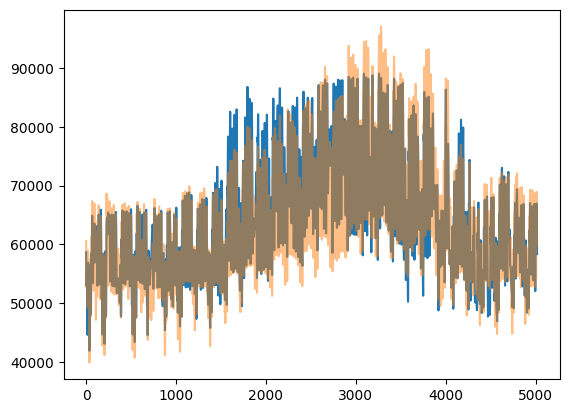

In [18]:
# 역변환
inverse_pred = mny.inverse_transform(test_preds)
inverse_real = mny.inverse_transform(test_y)

plt.plot(inverse_pred)
plt.plot(inverse_real, alpha=0.5)

# 설명력 확인
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
print(f"r2_score : {r2_score(inverse_real, inverse_pred)}")
print(f"root_mean_squared_error : {np.sqrt(mean_squared_error(inverse_real, inverse_pred))}")
print(f"mean_absolute_percentage_error:{mean_absolute_percentage_error(inverse_real, inverse_pred)}")